In [1]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

import torch
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from torchmetrics.regression import MeanAbsolutePercentageError

from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
ticker = "BTC-USD"
data = yf.download(ticker, start = "2020-01-01", end = pd.Timestamp.now().strftime('%Y-%m-%d'))

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
data

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095
...,...,...,...,...,...
2025-05-09,102970.851562,104297.492188,102343.093750,103239.125000,58198593958
2025-05-10,104696.328125,104961.765625,102830.484375,102973.710938,42276713994


In [4]:
cols = ['Close', 'Open', 'Volume']
data_normalized = StandardScaler().fit_transform(data[cols])

seq_len = 60
X = np.array([data_normalized[i:i+seq_len] for i in range(len(data_normalized)-seq_len)])
y = np.array(data_normalized[seq_len:])

split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

In [5]:
class RecurrentNeuralNet:
    def __init__(self, input_dim, hidden_dim):
        self.input_weights = np.random.randn(hidden_dim, input_dim) * 0.01
        self.hidden_weights = np.random.randn(hidden_dim, hidden_dim) * 0.01
        self.hidden_bias = np.zeros((hidden_dim, 1))
        self.output_weights = np.random.randn(input_dim, hidden_dim) * 0.01
        self.output_bias = np.zeros((input_dim, 1))

        # Кэш для обратного прохода
        self._cache = {'hidden_states': [], 'outputs': []}

    def predict(self, sequence, debug=False):
        current_state = np.zeros((self.hidden_weights.shape[0], 1))
        self._cache['hidden_states'] = [current_state]
        self._cache['outputs'] = []

        for step, input_vec in enumerate(sequence):
            input_vec = input_vec.reshape(-1, 1)

            if debug:
                self._debug_step(step, input_vec, current_state)

            # Прямой проход
            current_state = np.tanh(
                self.input_weights @ input_vec +
                self.hidden_weights @ current_state +
                self.hidden_bias
            )
            output = self.output_weights @ current_state + self.output_bias

            self._cache['hidden_states'].append(current_state)
            self._cache['outputs'].append(output)

        return self._cache['outputs'][-1]

    def learn(self, sequence, target, learning_rate=0.001):
        grads = {
            'W_xh': np.zeros_like(self.input_weights),
            'W_hh': np.zeros_like(self.hidden_weights),
            'b_h': np.zeros_like(self.hidden_bias),
            'W_hy': np.zeros_like(self.output_weights),
            'b_y': np.zeros_like(self.output_bias)
        }

        # Градиент выходного слоя
        output_error = (self._cache['outputs'][-1] - target.reshape(-1, 1))
        grads['W_hy'] = output_error @ self._cache['hidden_states'][-1].T
        grads['b_y'] = output_error

        # Обратное распространение через время
        dh = self.output_weights.T @ output_error
        for t in reversed(range(len(sequence))):
            x = sequence[t].reshape(-1, 1)
            h_prev = self._cache['hidden_states'][t]
            h_current = self._cache['hidden_states'][t+1]

            dtanh = (1 - h_current**2) * dh
            grads['W_xh'] += dtanh @ x.T
            grads['W_hh'] += dtanh @ h_prev.T
            grads['b_h'] += dtanh

            dh = self.hidden_weights.T @ dtanh

        # Обновление параметров с clipping градиентов
        self._update_parameters(grads, learning_rate, clip_value=5.0)

    def _debug_step(self, step, x, h):
        print(f'Step {step}:')
        print('Input transform:', self.input_weights @ x)
        print('Hidden transform:', self.hidden_weights @ h)
        print('Combined:', self.input_weights @ x + self.hidden_weights @ h)

    def _update_parameters(self, gradients, lr, clip_value):
        for grad in [gradients['W_xh'], gradients['W_hh'], gradients['W_hy']]:
            np.clip(grad, -clip_value, clip_value, out=grad)

        self.input_weights -= lr * gradients['W_xh']
        self.hidden_weights -= lr * gradients['W_hh']
        self.hidden_bias -= lr * gradients['b_h']
        self.output_weights -= lr * gradients['W_hy']
        self.output_bias -= lr * gradients['b_y']

In [11]:
# Параметры модели и обучения
input_size = len(cols)
hidden_size = 32
learning_rate = 0.001
epochs = 250

# Создание экземпляра модели
model = RecurrentNeuralNet(input_dim=input_size, hidden_dim=hidden_size)

# Callback-функция для логирования прогресса
def log_progress(epoch, loss, model):
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.6f}")

# Функция обучения с callback'ами
def train_with_callbacks(model, train_data, params, callbacks):
    X_train, y_train = train_data
    lr, epochs = params['lr'], params['epochs']
    loss_fn = MeanAbsolutePercentageError()

    loss_history = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        for x, y in zip(X_train, y_train):
            # Прямой проход
            prediction = model.predict(x)

            # Расчет ошибки
            loss = loss_fn(torch.Tensor(prediction), torch.Tensor(y).reshape(-1, 1))
            epoch_loss += loss.item()

            # Обратный проход и обновление весов
            model.learn(x, y, learning_rate=lr)

        avg_loss = epoch_loss / len(X_train)
        loss_history.append(avg_loss)  # Сохраняем потери за эпоху

        # Вызов callback'ов
        for callback in callbacks:
            callback(epoch, avg_loss, model)

    return loss_history  # Возвращаем историю потерь

loss_history = train_with_callbacks(
    model=model,
    train_data=(X_train, y_train),
    params={'lr': learning_rate, 'epochs': epochs},
    callbacks=[log_progress]
)

Epoch 0: Loss = 2.815261
Epoch 10: Loss = 1.126894
Epoch 20: Loss = 1.095632
Epoch 30: Loss = 1.056384
Epoch 40: Loss = 1.018063
Epoch 50: Loss = 0.963871
Epoch 60: Loss = 0.909179
Epoch 70: Loss = 0.912398
Epoch 80: Loss = 0.919643
Epoch 90: Loss = 0.918199
Epoch 100: Loss = 0.912958
Epoch 110: Loss = 0.908031
Epoch 120: Loss = 0.905492
Epoch 130: Loss = 0.904640
Epoch 140: Loss = 0.905453
Epoch 150: Loss = 0.906571
Epoch 160: Loss = 0.905924
Epoch 170: Loss = 0.902788
Epoch 180: Loss = 0.897712
Epoch 190: Loss = 0.891542
Epoch 200: Loss = 0.885791
Epoch 210: Loss = 0.885713
Epoch 220: Loss = 0.873226
Epoch 230: Loss = 0.857035
Epoch 240: Loss = 0.841272


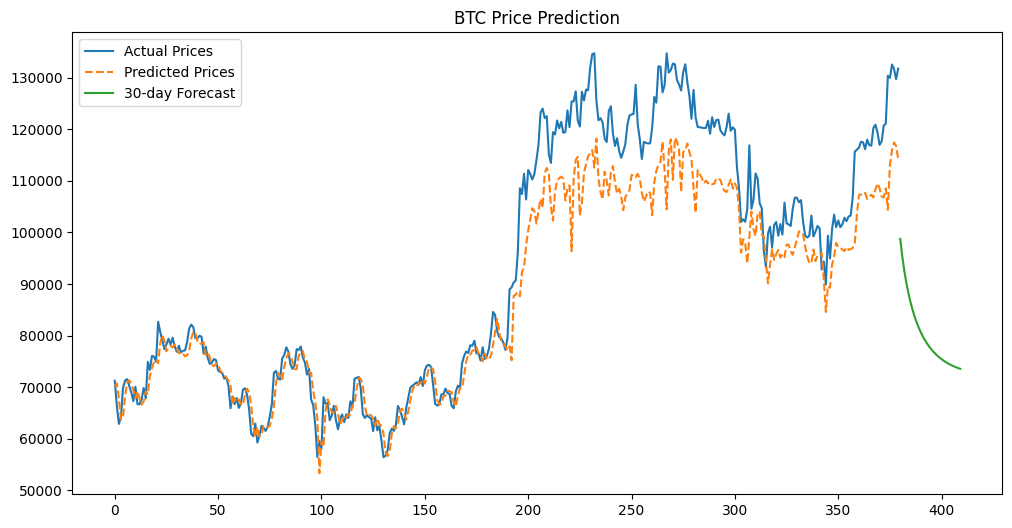

In [12]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()  # Устойчив к выбросам
data_normalized = scaler.fit_transform(data[cols])

def make_predictions(model, input_sequences, feature_scaler, feature_count):
    """
    Генерирует предсказания для набора входных последовательностей
    """
    predictions = []
    for seq in input_sequences:
        pred = model.predict(seq)
        predictions.append(pred)

    # Преобразуем и возвращаем в исходном масштабе
    return feature_scaler.inverse_transform(np.array(predictions).reshape(-1, feature_count))

# Прогноз на будущие периоды
def generate_forecast(model, last_sequence, feature_scaler, forecast_days=30, feature_count=3):
    """
    Генерирует прогноз на указанное количество дней вперед
    """
    forecast_results = []
    current_sequence = last_sequence.copy()

    for _ in range(forecast_days):
        next_pred = model.predict(current_sequence)
        forecast_results.append(next_pred)
        # Обновляем последовательность
        current_sequence = np.vstack([current_sequence[1:], next_pred.T])

    # Возвращаем прогноз в исходном масштабе
    return feature_scaler.inverse_transform(np.array(forecast_results).reshape(-1, feature_count))

# Получаем предсказания
test_predictions = make_predictions(
    model=model,
    input_sequences=X_test,
    feature_scaler=scaler,  # Используем наш scaler
    feature_count=len(cols)  # 3 features: Close, Open, Volume
)

# Прогноз на 30 дней
last_known_sequence = data_normalized[-seq_len:]
future_forecast = generate_forecast(
    model=model,
    last_sequence=last_known_sequence,
    feature_scaler=scaler,
    forecast_days=30,
    feature_count=len(cols)
)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(y_test)[:, 0], label='Actual Prices')
plt.plot(test_predictions[:, 0], '--', label='Predicted Prices')
plt.plot(range(len(y_test), len(y_test)+30), future_forecast[:, 0],
         label='30-day Forecast')
plt.title('BTC Price Prediction')
plt.legend()
plt.show()

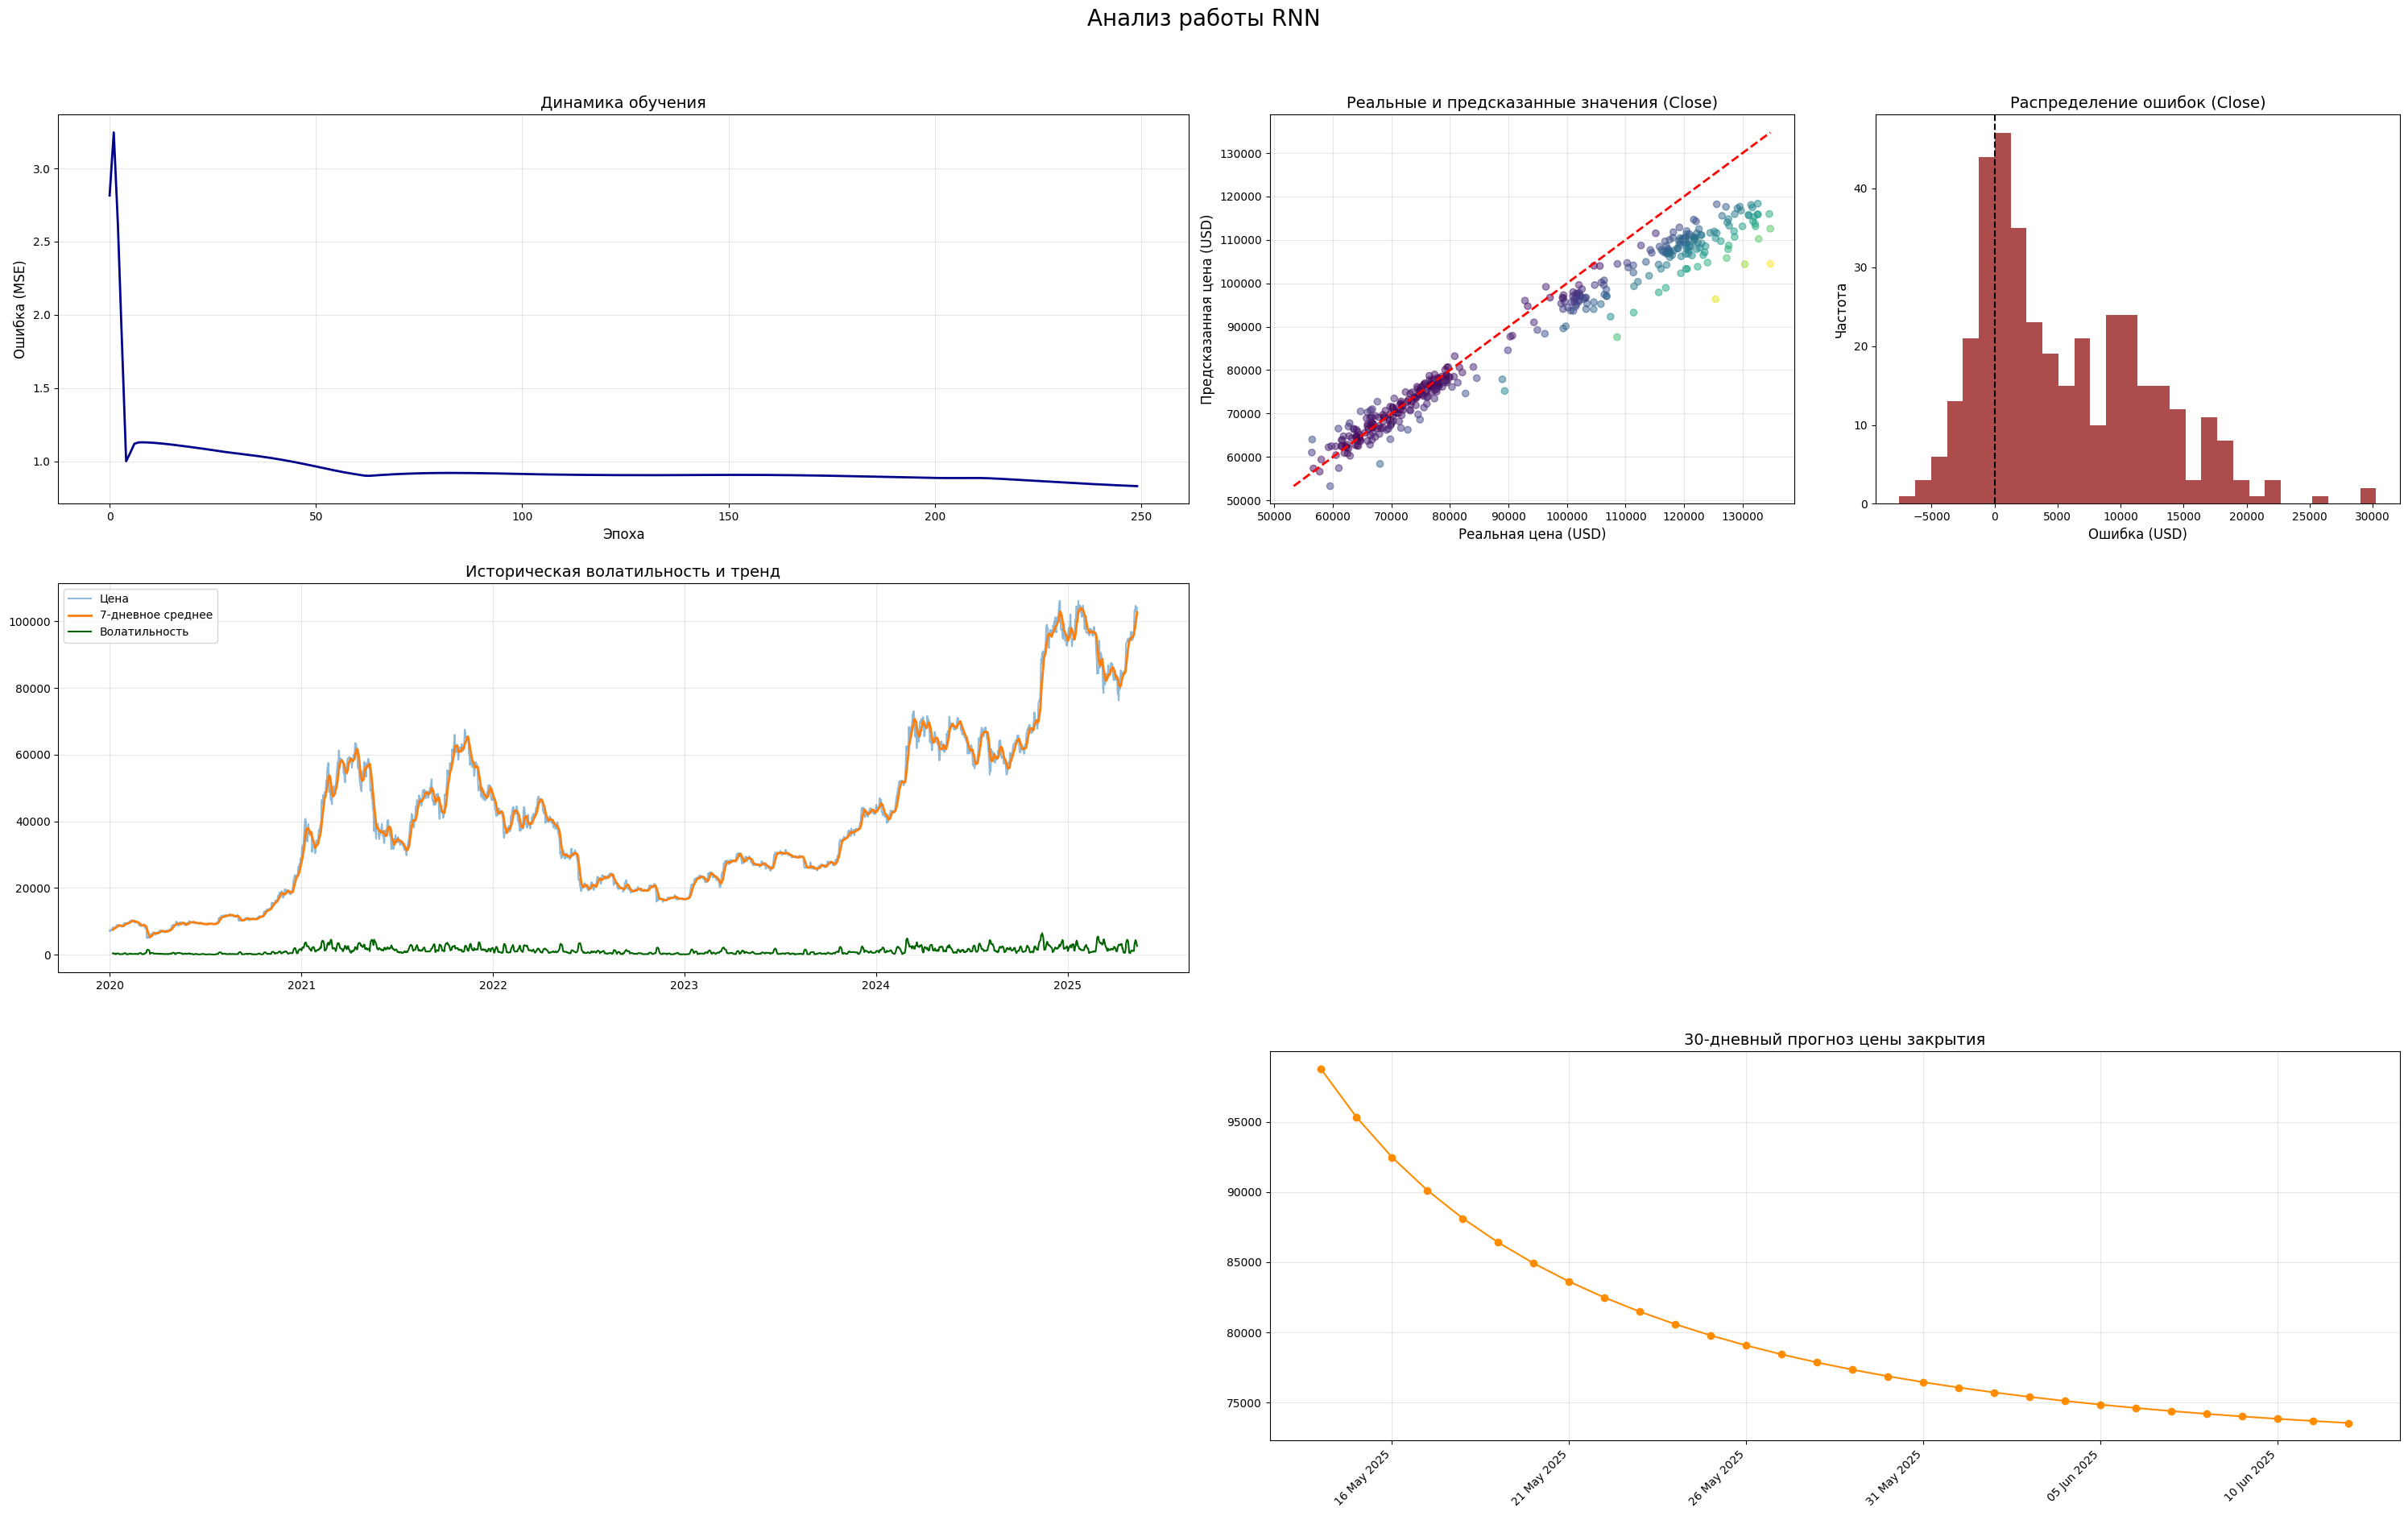

In [13]:
def create_analysis_dashboard(model, history, test_data, forecast, data, cols):
    y_test_inv, test_predictions_inv = test_data
    forecast_prices, forecast_dates = forecast

    fig = plt.figure(figsize=(30, 25))
    fig.suptitle("Анализ работы RNN", y=0.95, fontsize=20)

    # 1. График обучения
    ax1 = plt.subplot2grid((4, 4), (0, 0), colspan=2)
    ax1.plot(history, color="darkblue", linewidth=2)
    ax1.set_title("Динамика обучения", fontsize=14)
    ax1.set_xlabel("Эпоха", fontsize=12)
    ax1.set_ylabel("Ошибка (MSE)", fontsize=12)
    ax1.grid(True, alpha=0.3)

    # 2. Сравнение реальных и предсказанных значений
    ax2 = plt.subplot2grid((4, 4), (0, 2))
    ax2.scatter(y_test_inv[:, 0], test_predictions_inv[:, 0], alpha=0.5,
               c=np.abs(y_test_inv[:, 0] - test_predictions_inv[:, 0]), cmap="viridis")
    min_val = min(y_test_inv[:, 0].min(), test_predictions_inv[:, 0].min())
    max_val = max(y_test_inv[:, 0].max(), test_predictions_inv[:, 0].max())
    ax2.plot([min_val, max_val], [min_val, max_val], "--r", linewidth=2)
    ax2.set_title("Реальные и предсказанные значения (Close)", fontsize=14)
    ax2.set_xlabel("Реальная цена (USD)", fontsize=12)
    ax2.set_ylabel("Предсказанная цена (USD)", fontsize=12)
    ax2.grid(alpha=0.3)

    # 3. Распределение ошибок
    ax3 = plt.subplot2grid((4, 4), (0, 3))
    errors = y_test_inv[:, 0] - test_predictions_inv[:, 0]
    ax3.hist(errors, bins=30, color="darkred", alpha=0.7)
    ax3.set_title("Распределение ошибок (Close)", fontsize=14)
    ax3.set_xlabel("Ошибка (USD)", fontsize=12)
    ax3.set_ylabel("Частота", fontsize=12)
    ax3.axvline(x=0, color="black", linestyle="--")

    # 4. Скользящее среднее и волатильность
    ax4 = plt.subplot2grid((4, 4), (1, 0), colspan=2)
    window_size = 7
    data["MA_7"] = data["Close"].rolling(window=window_size).mean()
    data["Volatility"] = data["Close"].rolling(window=window_size).std()
    ax4.plot(data["Close"], label="Цена", alpha=0.5)
    ax4.plot(data["MA_7"], label="7-дневное среднее", linewidth=2)
    ax4.plot(data["Volatility"], label="Волатильность", color="darkgreen")
    ax4.set_title("Историческая волатильность и тренд", fontsize=14)
    ax4.legend()
    ax4.grid(alpha=0.3)

    # 8. Долгосрочный прогноз
    ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)
    ax8.plot(forecast_dates, forecast_prices, marker="o", markersize=6,
             linestyle="-", color="darkorange")
    ax8.set_title("30-дневный прогноз цены закрытия", fontsize=14)
    ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    ax8.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.setp(ax8.get_xticklabels(), rotation=45, ha="right")
    ax8.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Подготовка данных для визуализации
test_predictions = [model.predict(x) for x in X_test]
test_predictions_inv = scaler.inverse_transform(np.array(test_predictions).reshape(-1, len(cols)))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, len(cols)))

# Генерация прогноза
last_sequence = data_normalized[-seq_len:]
forecast_prices = []
current_seq = last_sequence.copy()
for _ in range(30):
    next_pred = model.predict(current_seq)
    forecast_prices.append(next_pred)
    current_seq = np.vstack([current_seq[1:], next_pred.T])
forecast_prices = scaler.inverse_transform(np.array(forecast_prices).reshape(-1, len(cols)))[:, 0]
forecast_dates = pd.date_range(start=data.index[-1], periods=31)[1:]

# Создание dashboard
create_analysis_dashboard(
    model=model,
    history=loss_history,
    test_data=(y_test_inv, test_predictions_inv),
    forecast=(forecast_prices, forecast_dates),
    data=data,
    cols=cols
)

Причины, по которым возможно падал прогноз:


*   Малое количество эпох при обучении. Вообще изначально было 20, что очевидно мало. Далее попробовал 150, потом 250 -- метрики улучшились. По графикам получили более точные предсказания
*   Также была изменена нормализация (тоже негативно влияала на прогноз). Вместо StandardScaler() использовался RobustScaler(), а он более устойчив к выбросам


*   Слишком мало признаков. Использовать только один Close не очень удачно, вместо этого берем целых три признака Close, Open и Volume
*   Возможно еще можно попробовать различные способы обучения модели. Я пробовал добавить Adam, но особых улучшений не наблюдалось


*   Архитектура модели. Пробовал добавить dropout, также особо ничего не поменялось. Видимо если и менять архитектуру, то нужно что-то принципиально другое



